# Elevator Analysis

*Finished Date: -th May 2021*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import defaultdict

import elevator
from elevator import elevator_simulation

import parameters_data
from parameters_data import get_parameters

from tqdm.notebook import tqdm

In [2]:
np.set_printoptions(suppress=True)
plt.style.use("bmh")
config = {'figure.figsize': (16, 4),
          'axes.titlesize': 18,
          'axes.labelsize': 12,
          'lines.linewidth': 2,
          'lines.markersize': 10,
          'xtick.labelsize': 10,
          'ytick.labelsize': 10,
          'axes.prop_cycle': plt.cycler(color=["darkmagenta", "saddlebrown", "darkcyan", "olivedrab", "darkseagreen", "darkkhaki", "darkgoldenrod", "deepskyblue", "firebrick", "palevioletred"]),}
plt.rcParams.update(config)

## Generate DataFrame

In [9]:
# parameters = get_parameters()

# runs = []
# num_runs = 200

# dispatching_algorithms = ['FIFO', 'IFOF', 'LOOK', 'LOOK_M']
# scenarios = ['residential_building', 'morning_rush', 'evening_rush', 'lunchtime']

# for scenario in tqdm(scenarios, leave=False):
    
#     for dispatching_algorithm in tqdm(dispatching_algorithms, leave=False):
    
#         for seed in tqdm(range(num_runs), leave=False):

#             data = elevator_simulation(dispatching_algorithm, scenario, seed+3, verbosity=0, **parameters)

#             users_served_df = pd.DataFrame(data['users_served'])

#             users_served_df['Queue Time'] = users_served_df['enter_elevator_time'] - users_served_df['arrive_time']
#             users_served_df['Elevator Time'] = users_served_df['arrive_destination_time'] - users_served_df['enter_elevator_time']
#             users_served_df['System Time'] = users_served_df['arrive_destination_time'] - users_served_df['arrive_time']

#             users_served_df['dispatching_algorithm'] = dispatching_algorithm
#             users_served_df['scenario'] = scenario

#             users_served_df = users_served_df[['Queue Time', 'Elevator Time', 'System Time', 'dispatching_algorithm', 'scenario']]

#             runs.append(users_served_df)
            
# df = pd.concat(runs)

# residential_building = df[df['scenario'] == 'Residential Building']
# aux = df[df['scenario'] != 'residential_building']
# aux = pd.concat([aux, residential_building, residential_building])
# aux['scenario'] = 'Business Day'
# df = pd.concat([df, aux])

# df['scenario'].replace({'residential_building': 'Residential Building', 'morning_rush': 'Morning Rush', 'lunchtime': 'Lunchtime', 'evening_rush': 'Evening Rush', 'business_day': 'Business Day'}, inplace=True)

## Bootstrapping

In [15]:
df = pd.read_csv('data.csv')
df.head()

,Queue Time,Elevator Time,System Time,dispatching_algorithm,scenario
0,1.000000,21.0,22.000000,FIFO,Residential Building
1,1.000000,21.0,22.000000,FIFO,Residential Building
2,13.291816,58.0,71.291816,FIFO,Residential Building
3,37.851427,31.0,68.851427,FIFO,Residential Building
4,66.788859,16.0,82.788859,FIFO,Residential Building


In [30]:
dispatching_algorithms = ['FIFO', 'IFOF', 'LOOK', 'LOOK_M']
scenarios = ['Residential Building', 'Morning Rush', 'Evening Rush', 'Lunchtime', 'Business Day']
metrics = ['Queue Time', 'Elevator Time', 'System Time']

for metric in metrics:
    for scenario in scenarios:
        for dispatching_algorithm in dispatching_algorithms:

            x = df[(df['scenario'] == scenario) & (df['dispatching_algorithm'] == dispatching_algorithm)][metric]
            mean_list = []
            for i in range(2000):
                sample = np.random.choice(x, size=len(x), replace=True)
                mean_list.append(sample.mean())
            print(f'{metric} - {scenario} - {dispatching_algorithm} - Mean: {np.mean(mean_list):.2f}')
    print('')

Queue Time - Residential Building - FIFO - Mean: 23.32
Queue Time - Residential Building - IFOF - Mean: 34.43
Queue Time - Residential Building - LOOK - Mean: 19.60
Queue Time - Residential Building - LOOK_M - Mean: 20.35
Queue Time - Morning Rush - FIFO - Mean: 594.67
Queue Time - Morning Rush - IFOF - Mean: 590.65
Queue Time - Morning Rush - LOOK - Mean: 572.36
Queue Time - Morning Rush - LOOK_M - Mean: 572.44
Queue Time - Evening Rush - FIFO - Mean: 559.97
Queue Time - Evening Rush - IFOF - Mean: 623.47
Queue Time - Evening Rush - LOOK - Mean: 58.84
Queue Time - Evening Rush - LOOK_M - Mean: 58.87
Queue Time - Lunchtime - FIFO - Mean: 1142.27
Queue Time - Lunchtime - IFOF - Mean: 1062.63
Queue Time - Lunchtime - LOOK - Mean: 1031.54
Queue Time - Lunchtime - LOOK_M - Mean: 1031.30
Queue Time - Business Day - FIFO - Mean: 952.94
Queue Time - Business Day - IFOF - Mean: 876.71
Queue Time - Business Day - LOOK - Mean: 773.51
Queue Time - Business Day - LOOK_M - Mean: 773.50

Elevator Ti

## Pointplots

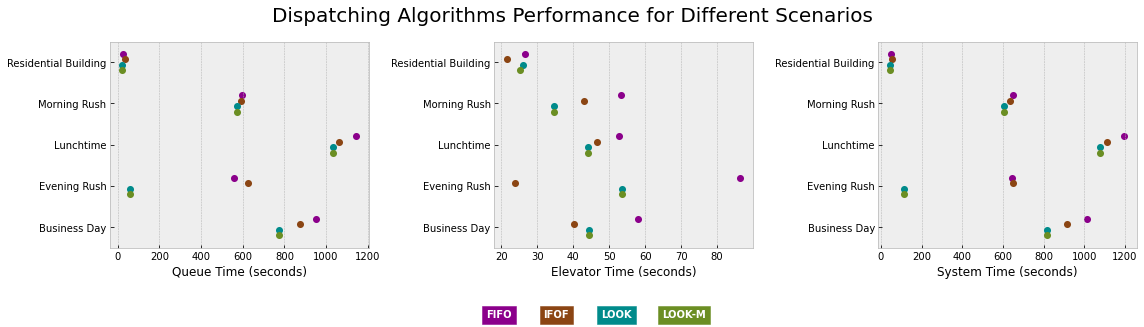

In [10]:
column_order = ['Residential Building', 'Morning Rush', 'Lunchtime', 'Evening Rush', 'Business Day']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.pointplot(x='Queue Time', y='scenario', data=df, hue='dispatching_algorithm', orient='h', dodge=0.4, scale=0.6, capsize=0, join=False, order=column_order, errwidth=1.5, label=[''], ax=axes[0])
axes[0].get_legend().remove()
axes[0].set_xlabel('Queue Time (seconds)')
axes[0].set_ylabel('')

sns.pointplot(x='Elevator Time', y='scenario', data=df, hue='dispatching_algorithm', orient='h', dodge=0.4, scale=0.6, capsize=0, join=False, order=column_order, errwidth=1.5, label=[''], ax=axes[1])
axes[1].get_legend().remove()
axes[1].set_xlabel('Elevator Time (seconds)')
axes[1].set_ylabel('')

sns.pointplot(x='System Time', y='scenario', data=df, hue='dispatching_algorithm', orient='h', dodge=0.4, scale=0.6, capsize=0, join=False, order=column_order, errwidth=1.5, label=[''], ax=axes[2])
axes[2].get_legend().remove()
axes[2].set_xlabel('System Time (seconds)')
axes[2].set_ylabel('')

plt.figtext(0.425, -0.1, 'FIFO', color='white', backgroundcolor='darkmagenta', fontsize=10, fontweight='bold', ha='left')
plt.figtext(0.475, -0.1, 'IFOF', color='white', backgroundcolor='saddlebrown', fontsize=10, fontweight='bold', ha='left')
plt.figtext(0.525, -0.1, 'LOOK', color='white', backgroundcolor='darkcyan', fontsize=10, fontweight='bold', ha='left')
plt.figtext(0.578, -0.1, 'LOOK-M', color='white', backgroundcolor='olivedrab', fontsize=10, fontweight='bold', ha='left')

plt.suptitle(f'Dispatching Algorithms Performance for Different Scenarios', fontsize=20)
plt.tight_layout()
plt.savefig('dispatching_algorithms.pdf', bbox_inches='tight')
plt.show()